In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('1.ushape.csv',header=None,names=['X','Y','class'])

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


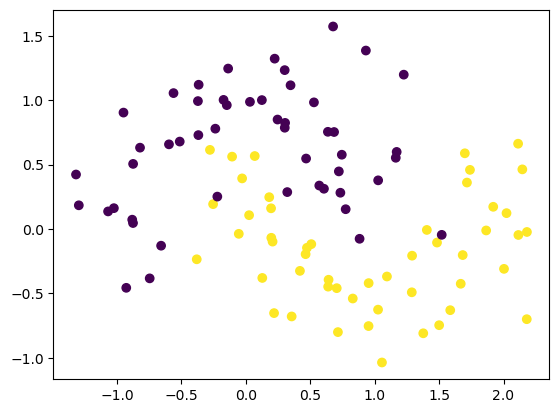

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# xavier

In [8]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\cipl\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.get_weights()

[array([[ 0.6511949 , -0.18277335, -0.25175527,  0.05776447, -0.40463334,
         -0.53949666, -0.4501629 ,  0.10604179, -0.23204723,  0.42231256],
        [-0.21523535, -0.06382918, -0.04689783,  0.4887554 , -0.4328763 ,
         -0.08474553, -0.69326425, -0.33346805, -0.07774812, -0.00775707]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.00354886, -0.32328033, -0.4878977 , -0.50974077,  0.41376185,
         -0.19581988,  0.45375323, -0.3837002 , -0.10752788, -0.30456665],
        [-0.1552741 ,  0.356319  ,  0.23186237,  0.44141138, -0.25549564,
          0.18362552, -0.4384135 ,  0.07481539, -0.45666826,  0.33993256],
        [-0.33212918, -0.52625716, -0.31638938,  0.07393026, -0.5059202 ,
          0.01721507,  0.32586336, -0.1678836 , -0.30101663,  0.04411316],
        [ 0.07564068,  0.08135545,  0.13961565, -0.04547948, -0.14824629,
         -0.15575701,  0.09795868, -0.46284217,  0.31612796,  0.24463522],
        [ 0.43483

In [16]:
initial_weights = model.get_weights()

In [17]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [18]:
model.set_weights(initial_weights)

In [19]:
model.get_weights()

[array([[ 0.9565642 , -0.7862346 ,  1.1351018 ,  0.3184282 ,  0.21062507,
          0.5269412 , -2.2680113 , -0.04655565,  0.5313057 ,  0.9071228 ],
        [ 0.8013983 ,  0.04980956, -1.4182333 ,  0.78127086, -0.38944843,
          0.8021151 ,  0.84863365,  0.86355513,  0.64496386,  0.6428347 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.15617609, -0.67113465,  0.09505775,  0.37435076,  0.50125366,
          0.0951369 , -0.5706605 ,  0.58085847, -0.43621486,  0.13835993],
        [ 0.05388015,  0.37564057,  0.45441508,  0.41222858,  0.44579932,
          0.01900241,  0.30106124,  0.1036417 ,  0.04829611,  0.00403513],
        [ 0.22495867, -0.13019004, -0.0874364 , -0.21575399,  0.5355408 ,
         -0.11548744, -0.24069148, -0.03741916, -0.3578134 , -0.33433822],
        [-0.5897192 , -0.27668265, -0.25263602,  0.21229988, -0.12163541,
         -0.44171783,  0.52829355, -0.4670117 , -0.22142239,  0.15301472],
        [-0.19464

In [20]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [21]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.2820 - loss: 0.7824 - val_accuracy: 0.1500 - val_loss: 0.7941
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2859 - loss: 0.7585 - val_accuracy: 0.1500 - val_loss: 0.7701
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2445 - loss: 0.7531 - val_accuracy: 0.1500 - val_loss: 0.7476
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2641 - loss: 0.7305 - val_accuracy: 0.1500 - val_loss: 0.7270
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3273 - loss: 0.7166 - val_accuracy: 0.3500 - val_loss: 0.7077
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4516 - loss: 0.7022 - val_accuracy: 0.6000 - val_loss: 0.6889
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6125 - loss: 0.6875 - val_accuracy: 0.7000 - val_loss: 0.6706
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6742 - loss: 0.6762 - val_accuracy: 0.8500 - val_loss

In [34]:
model.get_weights()

[array([[ 0.97856635, -0.63321644,  0.929749  ,  0.23856132,  0.17984363,
          0.5719298 , -2.106291  , -0.20270279,  0.40221068,  0.9555995 ],
        [ 0.7783613 ,  0.0554503 , -1.6300358 ,  0.7799653 , -0.44997713,
          0.740424  ,  0.8986788 ,  0.9932707 ,  0.73380935,  0.735538  ]],
       dtype=float32),
 array([ 0.2054392 ,  0.13210447, -0.12772201, -0.02477004, -0.0215346 ,
         0.08800029, -0.1054349 , -0.03936791, -0.14753127, -0.15481208],
       dtype=float32),
 array([[ 1.72597274e-01, -5.47485948e-01,  1.18896730e-01,
          5.01161456e-01,  5.32260537e-01,  2.03658476e-01,
         -6.04607224e-01,  5.65809011e-01, -3.78087729e-01,
          1.99942186e-01],
        [ 1.37184307e-01,  3.67414445e-01,  3.62135708e-01,
          3.14092189e-01,  3.30807030e-01,  3.14187370e-02,
          2.36300275e-01, -1.56085622e-02, -3.13664973e-02,
          8.96495581e-02],
        [ 1.41870767e-01, -2.19584286e-01, -2.28717737e-03,
         -3.41883838e-01,  6.48083

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step


<Axes: >

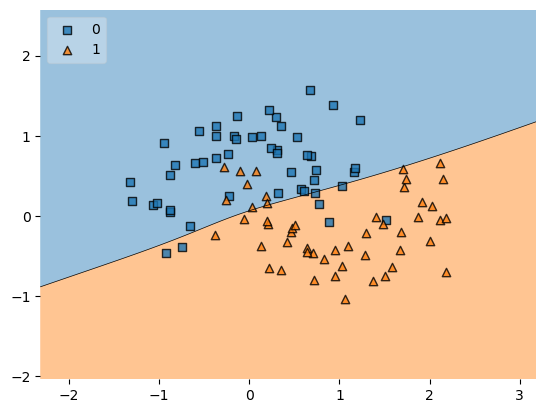

In [36]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

# He

In [38]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

C:\Users\cipl\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
initial_weights = model.get_weights()
initial_weights

[array([[-1.1365634 , -0.1814076 ,  0.9678107 , -0.93572044,  1.5757455 ,
         -1.410482  , -0.6878748 ,  0.54174167, -1.2157482 ,  0.81817824],
        [ 0.88731664,  2.1800537 ,  1.5909822 ,  0.5286047 , -0.08035893,
          0.45305768,  0.3489565 , -0.19929948, -1.2309743 , -1.9322681 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.54187775,  0.18301262, -0.19532965,  0.66077864, -0.3638109 ,
         -0.7852939 ,  0.65350866,  0.94934183,  0.28578815,  0.3132368 ],
        [ 0.39038318, -0.22052987, -0.07687247,  0.05360338, -0.10950566,
          0.00517803, -0.17492607,  0.00142094, -0.21868844, -0.2740032 ],
        [-0.6962791 ,  0.36625162,  0.34536055, -0.28582612, -0.21950363,
          0.5183341 ,  0.49839357,  0.19893466,  0.71137244, -0.15539466],
        [ 0.4133088 ,  0.822999  , -0.74047875,  0.8771694 ,  0.05829151,
          0.20843995, -0.24657097,  0.18891402,  0.45058975,  0.6003748 ],
        [ 0.00557

In [42]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [44]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 209ms/step - accuracy: 0.3812 - loss: 0.6887 - val_accuracy: 0.6500 - val_loss: 0.5791
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4484 - loss: 0.6594 - val_accuracy: 0.7500 - val_loss: 0.5607
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4891 - loss: 0.6521 - val_accuracy: 0.7000 - val_loss: 0.5432
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4766 - loss: 0.6562 - val_accuracy: 0.7500 - val_loss: 0.5289
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5367 - loss: 0.6372 - val_accuracy: 0.7500 - val_loss: 0.5149
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5445 - loss: 0.6197 - val_accuracy: 0.7500 - val_loss: 0.5011
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5750 - loss: 0.6142 - val_accuracy: 0.7500 - val_loss: 0.4871
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6812 - loss: 0.5902 - val_accuracy: 0.8500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step


<Axes: >

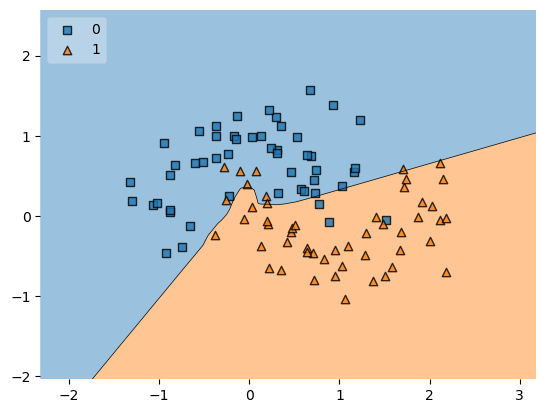

In [45]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [61]:
(np.random.randn(10,10)*0.01).min()

-0.021054262887154555

In [62]:
(np.random.randn(10,10)*0.01).max()

0.023149877698936994